# GWHD per-domain AP50-95 (train)

This notebook runs inference with the trained weight, computes per-domain AP@0.50:0.95 on the train split, and saves results to results/gwhd_domain_ap/.

Run cells in order. Heavy steps can be skipped if cached outputs exist. Set RUN_INFERENCE=True to run model inference.
For AP50-95, the prediction confidence cutoff is kept very low so low-score detections are not truncated before evaluation.

In [2]:
%pip install pycocotools ultralytics pandas matplotlib pillow tqdm

/home/khanh/Projects/DifficultyAgri/venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path
import json
import os
ROOT = Path('/home/khanh/Projects/DifficultyAgri')
TRAIN_CSV = ROOT / 'datasets/global_wheat_head/raw_v2/gwhd_2021/competition_train.csv'
TRAIN_IMG_DIR = ROOT / 'datasets/global_wheat_head/yolo_format_v2/train/images'
WEIGHT = ROOT / 'results/01_only_training_gwhd_2021/Step_2_Train_and_Evaluate_BASELINE_MODEL/train_results/best.pt'
OUT_DIR = ROOT / 'results/gwhd_domain_ap'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print('TRAIN_CSV:', TRAIN_CSV)
print('TRAIN_IMG_DIR:', TRAIN_IMG_DIR)
print('WEIGHT:', WEIGHT)
print('OUT_DIR:', OUT_DIR)

TRAIN_CSV: /home/khanh/Projects/DifficultyAgri/datasets/global_wheat_head/raw_v2/gwhd_2021/competition_train.csv
TRAIN_IMG_DIR: /home/khanh/Projects/DifficultyAgri/datasets/global_wheat_head/yolo_format_v2/train/images
WEIGHT: /home/khanh/Projects/DifficultyAgri/results/01_only_training_gwhd_2021/Step_2_Train_and_Evaluate_BASELINE_MODEL/train_results/best.pt
OUT_DIR: /home/khanh/Projects/DifficultyAgri/results/gwhd_domain_ap


In [4]:
# Create COCO-format GT for train set
import pandas as pd
from PIL import Image
from pathlib import Path

def parse_csv_to_gt(csv_path, images_dir):
    rows = pd.read_csv(csv_path)
    images = []
    annotations = []
    ann_id = 1
    img_id = 1
    name_to_id = {}
    for _, r in rows.iterrows():
        name = r['image_name']
        domain = r['domain'] if 'domain' in r else ''
        img_path = Path(images_dir) / name
        if not img_path.exists():
            continue
        w,h = Image.open(img_path).size
        images.append({'id': img_id, 'file_name': name, 'width': w, 'height': h, 'domain': domain})
        name_to_id[name] = img_id
        boxes = r['BoxesString'] if not pd.isna(r['BoxesString']) else ''
        if isinstance(boxes, str) and boxes.lower().strip() not in ['', 'no_box']:
            for part in boxes.split(';'):
                part = part.strip()
                if not part:
                    continue
                coords = [float(x) for x in part.split()]
                if len(coords) == 4:
                    x1,y1,x2,y2 = coords
                    bw = x2-x1
                    bh = y2-y1
                    annotations.append({'id': ann_id, 'image_id': img_id, 'category_id': 1, 'bbox':[x1,y1,bw,bh], 'area':bw*bh, 'iscrowd':0})
                    ann_id += 1
        img_id += 1
    gt = {'images': images, 'annotations': annotations, 'categories': [{'id':1,'name':'wheat_head'}]}
    return gt, name_to_id

gt, name_to_id = parse_csv_to_gt(TRAIN_CSV, TRAIN_IMG_DIR)
with open(OUT_DIR / 'gwhd_train_gt.json','w') as f:
    json.dump(gt, f)

print('GT images:', len(gt['images']), 'annotations:', len(gt['annotations']))

GT images: 3657 annotations: 163690


In [5]:
# Run inference (set RUN_INFERENCE=True to run; chunked to avoid CUDA OOM)
RUN_INFERENCE = False
USE_GPU = True
CHUNK_SIZE = 32
CONF_THRES = 0.001

from ultralytics import YOLO
import torch
from pathlib import Path
import json

preds_path = OUT_DIR / 'gwhd_train_preds.json'
if RUN_INFERENCE or not preds_path.exists():
    device = 'cuda' if (torch.cuda.is_available() and USE_GPU) else 'cpu'
    print('Using device:', device)
    model = YOLO(str(WEIGHT))
    img_list = [str(TRAIN_IMG_DIR / im['file_name']) for im in gt['images']]
    all_preds = []
    try:
        for i in range(0, len(img_list), CHUNK_SIZE):
            chunk = img_list[i:i+CHUNK_SIZE]
            print(f'Predicting chunk {i}..{i+len(chunk)} (size={len(chunk)})')
            results = model.predict(source=chunk, conf=CONF_THRES, iou=0.45, max_det=1000, device=device)
            for res, img_path in zip(results, chunk):
                img_name = Path(img_path).name
                dets = getattr(res, 'boxes', None)
                if dets is None or len(dets)==0:
                    continue
                for box in dets:
                    xyxy = box.xyxy.tolist()[0]
                    x1,y1,x2,y2 = xyxy
                    w = x2-x1
                    h = y2-y1
                    score = float(box.conf.tolist()[0])
                    all_preds.append({'image_id': img_name, 'bbox':[float(x1),float(y1),float(w),float(h)], 'score': score, 'category_id':1})
            if device.startswith('cuda'):
                torch.cuda.empty_cache()
    except RuntimeError as e:
        print('RuntimeError during inference:', e)
        if 'out of memory' in str(e).lower():
            print('Falling back to CPU and retrying remaining images')
            device = 'cpu'
            for i in range(0, len(img_list), CHUNK_SIZE):
                chunk = img_list[i:i+CHUNK_SIZE]
                results = model.predict(source=chunk, conf=CONF_THRES, iou=0.45, max_det=1000, device=device)
                for res, img_path in zip(results, chunk):
                    img_name = Path(img_path).name
                    dets = getattr(res, 'boxes', None)
                    if dets is None or len(dets)==0:
                        continue
                    for box in dets:
                        xyxy = box.xyxy.tolist()[0]
                        x1,y1,x2,y2 = xyxy
                        w = x2-x1
                        h = y2-y1
                        score = float(box.conf.tolist()[0])
                        all_preds.append({'image_id': img_name, 'bbox':[float(x1),float(y1),float(w),float(h)], 'score': score, 'category_id':1})
    # convert to COCO preds
    coco_preds = []
    for p in all_preds:
        if p['image_id'] not in name_to_id:
            continue
        coco_preds.append({'image_id': name_to_id[p['image_id']], 'category_id': p['category_id'], 'bbox': p['bbox'], 'score': p['score']})
    with open(preds_path,'w') as f:
        json.dump(coco_preds, f)
    print('Saved preds to', preds_path)
else:
    print('Loading cached predictions from', preds_path)
    coco_preds = json.loads(preds_path.read_text())

Loading cached predictions from /home/khanh/Projects/DifficultyAgri/results/gwhd_domain_ap/gwhd_train_preds.json


            domain      0.50      0.55      0.60      0.65      0.70  \
0       Arvalis_10  0.929513  0.927253  0.920996  0.915415  0.901068   
1           Rres_1  0.973006  0.966175  0.954901  0.933270  0.891920   
2           ETHZ_1  0.960944  0.948999  0.929357  0.894912  0.835276   
3           NMBU_2  0.901115  0.889273  0.876968  0.858324  0.820678   
4          Inrae_1  0.962459  0.954706  0.941583  0.918213  0.866351   
5       Arvalis_11  0.835607  0.819192  0.803935  0.782889  0.754324   
6           NMBU_1  0.914357  0.899433  0.877836  0.840175  0.790104   
7        Arvalis_6  0.954047  0.944831  0.926505  0.894924  0.821088   
8   ULiège-GxABT_1  0.846724  0.830956  0.820084  0.796271  0.767193   
9        Arvalis_8  0.873747  0.862521  0.835819  0.793731  0.713514   
10       Arvalis_5  0.922467  0.901683  0.869882  0.816566  0.723142   
11       Arvalis_9  0.859127  0.843820  0.818970  0.778404  0.691516   
12      Arvalis_12  0.772019  0.756417  0.733456  0.697731  0.63

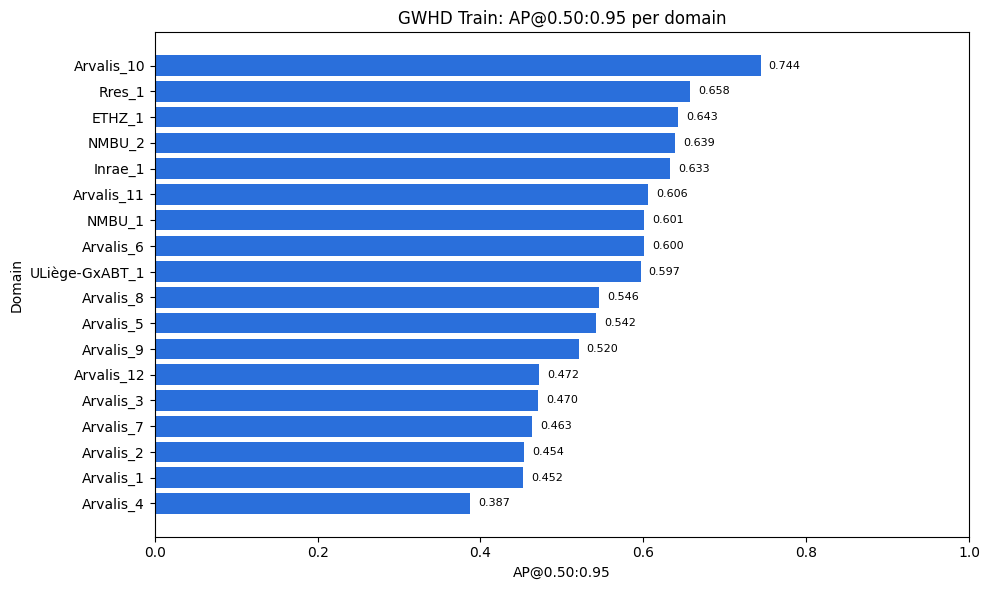

In [6]:
# Evaluate per-domain AP@0.50:0.95 with greedy IoU matching and plot results
import json
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

preds_path = OUT_DIR / 'gwhd_train_preds.json'
gt_path = OUT_DIR / 'gwhd_train_gt.json'

gt_data = json.loads(gt_path.read_text())
preds_data = json.loads(preds_path.read_text())

image_id_to_domain = {int(im['id']): im.get('domain', '') for im in gt_data['images']}

gt_boxes_by_domain = defaultdict(lambda: defaultdict(list))
for ann in gt_data['annotations']:
    image_id = int(ann['image_id'])
    domain = image_id_to_domain.get(image_id, '')
    gt_boxes_by_domain[domain][image_id].append({
        'bbox': [float(v) for v in ann['bbox']],
        'matched': False,
    })

preds_by_domain = defaultdict(list)
for pred in preds_data:
    image_id = int(pred['image_id'])
    domain = image_id_to_domain.get(image_id, '')
    preds_by_domain[domain].append({
        'image_id': image_id,
        'bbox': [float(v) for v in pred['bbox']],
        'score': float(pred['score']),
    })

def bbox_iou_xywh(box_a, box_b):
    ax1, ay1, aw, ah = box_a
    bx1, by1, bw, bh = box_b
    ax2 = ax1 + aw
    ay2 = ay1 + ah
    bx2 = bx1 + bw
    by2 = by1 + bh
    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)
    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h
    area_a = max(0.0, aw) * max(0.0, ah)
    area_b = max(0.0, bw) * max(0.0, bh)
    union = area_a + area_b - inter_area
    return 0.0 if union <= 0 else inter_area / union

def average_precision_from_pr(recalls, precisions):
    if len(recalls) == 0:
        return 0.0
    mrec = np.concatenate(([0.0], recalls, [1.0]))
    mpre = np.concatenate(([0.0], precisions, [0.0]))
    mpre = np.maximum.accumulate(mpre[::-1])[::-1]
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    return float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]))

def ap_at_iou_threshold(iou_threshold):
    domain_rows = []
    for domain, image_to_gts in gt_boxes_by_domain.items():
        preds = sorted(preds_by_domain.get(domain, []), key=lambda x: x['score'], reverse=True)
        total_gt = sum(len(v) for v in image_to_gts.values())
        if total_gt == 0:
            continue

        matched_flags = {image_id: [False] * len(boxes) for image_id, boxes in image_to_gts.items()}
        tp = []
        fp = []

        for pred in preds:
            image_id = pred['image_id']
            gt_boxes = image_to_gts.get(image_id, [])
            if not gt_boxes:
                tp.append(0)
                fp.append(1)
                continue

            best_iou = 0.0
            best_idx = -1
            for idx, gt_box in enumerate(gt_boxes):
                if matched_flags[image_id][idx]:
                    continue
                iou = bbox_iou_xywh(pred['bbox'], gt_box['bbox'])
                if iou > best_iou:
                    best_iou = iou
                    best_idx = idx

            if best_iou >= iou_threshold and best_idx >= 0:
                matched_flags[image_id][best_idx] = True
                tp.append(1)
                fp.append(0)
            else:
                tp.append(0)
                fp.append(1)

        tp = np.cumsum(tp, dtype=float)
        fp = np.cumsum(fp, dtype=float)
        recalls = tp / max(total_gt, 1)
        precisions = tp / np.maximum(tp + fp, 1e-12)
        ap = average_precision_from_pr(recalls, precisions)
        domain_rows.append({
            'domain': domain,
            'AP': ap,
            'n_images': len(image_to_gts),
            'n_gt': total_gt,
            'n_preds': len(preds),
        })
    return pd.DataFrame(domain_rows)

thresholds = np.arange(0.5, 1.0, 0.05)
per_threshold = []
for iou_threshold in thresholds:
    per_threshold.append(ap_at_iou_threshold(float(iou_threshold)).set_index('domain')['AP'])
ap_matrix = pd.concat(per_threshold, axis=1)
ap_matrix.columns = [f'{thr:.2f}' for thr in thresholds]
df = ap_matrix.copy()
df['AP50-95'] = df.mean(axis=1)
df = df.reset_index().rename(columns={'index': 'domain'})
domain_info = ap_at_iou_threshold(0.5).drop(columns=['AP'])
df = df.merge(domain_info, on='domain', how='left')
df = df.sort_values('AP50-95', ascending=False).reset_index(drop=True)
df.to_csv(OUT_DIR / 'gwhd_train_domain_ap5095.csv', index=False)
df.to_csv(OUT_DIR / 'gwhd_train_domain_ap.csv', index=False)

plot_df = df.sort_values('AP50-95', ascending=True)
plt.figure(figsize=(max(10, 0.35 * len(plot_df)), max(6, 0.25 * len(plot_df))))
bars = plt.barh(plot_df['domain'], plot_df['AP50-95'], color='#2a6fdb')
plt.xlabel('AP@0.50:0.95')
plt.ylabel('Domain')
plt.xlim(0, 1)
plt.title('GWHD Train: AP@0.50:0.95 per domain')
for bar, value in zip(bars, plot_df['AP50-95']):
    plt.text(min(0.99, value + 0.01), bar.get_y() + bar.get_height() / 2, f'{value:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / 'gwhd_train_domain_ap5095.png', dpi=200)
plt.savefig(OUT_DIR / 'gwhd_train_domain_ap.png', dpi=200)

print(df.head(30))
print('Saved:', OUT_DIR / 'gwhd_train_domain_ap5095.csv')
print('Saved:', OUT_DIR / 'gwhd_train_domain_ap5095.png')
plt.show()

In [7]:
# Score vs domain AP correlation analysis (using designed difficulty scores)
import json
import numpy as np
import pandas as pd
from scipy import stats
from pathlib import Path

# Load designed scores
score_path = Path('/home/khanh/Projects/DifficultyAgri/results/02_only_scoring_gwhd_2021/Step_3_Scoring_Dataset/score_results.json')
with open(score_path) as f:
    score_data = json.load(f)

# Create image_path to difficulty_score mapping
image_path_to_score = {}
for img_entry in score_data.get('image_difficulties', []):
    img_path = img_entry['image_path']
    difficulty_score = img_entry['difficulty_score']
    image_path_to_score[img_path] = difficulty_score

# Load GT to map image paths to domains
gt_path = OUT_DIR / 'gwhd_train_gt.json'
gt_data = json.loads(gt_path.read_text())

# Create image_path to domain mapping from GT
image_path_to_domain = {}
for im in gt_data['images']:
    file_name = im['file_name']
    domain = im.get('domain', '')
    # Reconstruct full path
    img_path = str(TRAIN_IMG_DIR / file_name)
    image_path_to_domain[img_path] = domain

# Group difficulty scores by domain and compute median
scores_by_domain = {}
for img_path, score in image_path_to_score.items():
    domain = image_path_to_domain.get(img_path)
    if domain:
        if domain not in scores_by_domain:
            scores_by_domain[domain] = []
        scores_by_domain[domain].append(score)

median_scores = {}
for domain, scores in scores_by_domain.items():
    median_scores[domain] = np.median(scores)

print(f"Loaded {len(image_path_to_score)} image difficulty scores")
print(f"Found {len(median_scores)} domains with scores")

# Load AP50-95 results
ap_csv_path = OUT_DIR / 'gwhd_train_domain_ap5095.csv'
ap_df = pd.read_csv(ap_csv_path)

# Create correlation table
correlation_data = []
for _, row in ap_df.iterrows():
    domain = row['domain']
    ap_score = row['AP50-95']
    median_score = median_scores.get(domain, np.nan)
    correlation_data.append({
        'domain': domain,
        'median_difficulty_score': median_score,
        'AP50-95': ap_score,
    })

corr_df = pd.DataFrame(correlation_data)
corr_df = corr_df.sort_values('AP50-95', ascending=False).reset_index(drop=True)

# Compute Pearson and Spearman correlations
pearson_corr, pearson_pval = stats.pearsonr(corr_df['median_difficulty_score'], corr_df['AP50-95'])
spearman_corr, spearman_pval = stats.spearmanr(corr_df['median_difficulty_score'], corr_df['AP50-95'])

print("=== Designed Score vs Domain AP Correlation ===")
print(f"\nPearson correlation: {pearson_corr:.4f} (p-value: {pearson_pval:.4f})")
print(f"Spearman correlation: {spearman_corr:.4f} (p-value: {spearman_pval:.4f})")
print("\n=== Correlation Table ===")
print(corr_df.to_string(index=False))

# Save correlation table
corr_df.to_csv(OUT_DIR / 'gwhd_train_designed_score_vs_ap_correlation.csv', index=False)
print(f"\nSaved correlation table to {OUT_DIR / 'gwhd_train_designed_score_vs_ap_correlation.csv'}")


Loaded 3655 image difficulty scores
Found 18 domains with scores
=== Designed Score vs Domain AP Correlation ===

Pearson correlation: -0.9047 (p-value: 0.0000)
Spearman correlation: -0.8989 (p-value: 0.0000)

=== Correlation Table ===
        domain  median_difficulty_score  AP50-95
    Arvalis_10                 0.200356 0.743984
        Rres_1                 0.226929 0.657739
        ETHZ_1                 0.267666 0.643182
        NMBU_2                 0.299202 0.638925
       Inrae_1                 0.263983 0.632950
    Arvalis_11                 0.358056 0.605929
        NMBU_1                 0.334666 0.600643
     Arvalis_6                 0.288658 0.600448
ULiège-GxABT_1                 0.380055 0.596565
     Arvalis_8                 0.342279 0.545962
     Arvalis_5                 0.341839 0.542025
     Arvalis_9                 0.371833 0.520499
    Arvalis_12                 0.395199 0.472020
     Arvalis_3                 0.349954 0.470475
     Arvalis_7               

Saved scatter plot to /home/khanh/Projects/DifficultyAgri/results/gwhd_domain_ap/gwhd_train_designed_score_vs_ap_scatter.png


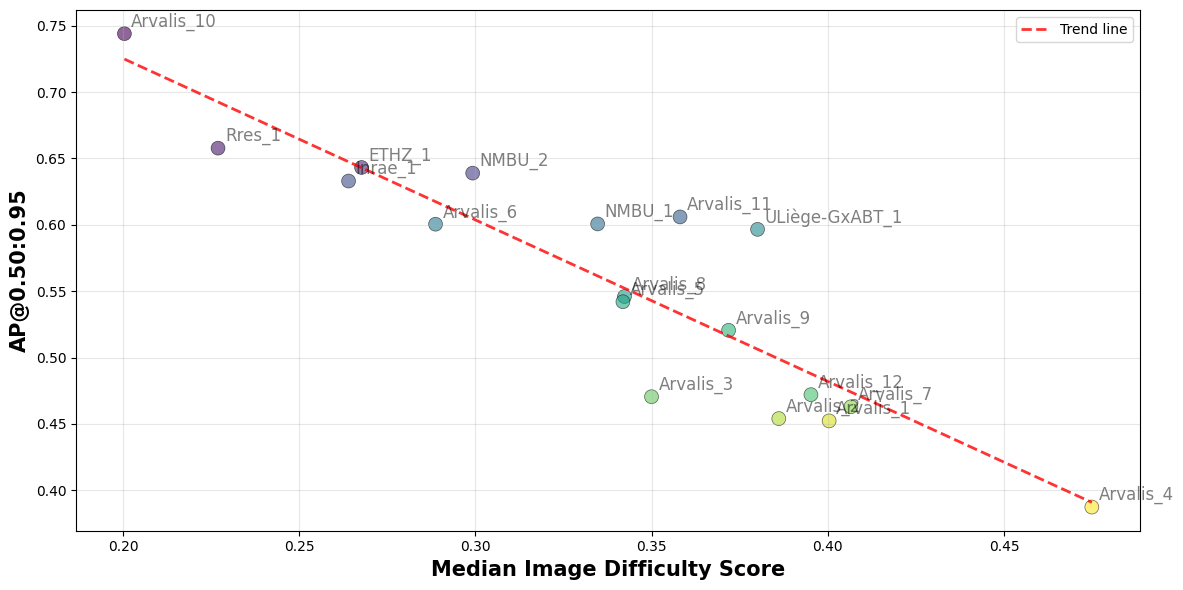

In [23]:
# Scatter plot: median_difficulty_score vs AP50-95 with correlation visualization
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 6))

# Plot scatter points
scatter = ax.scatter(corr_df['median_difficulty_score'], corr_df['AP50-95'], 
                     s=100, alpha=0.6, c=range(len(corr_df)), cmap='viridis', edgecolors='black', linewidth=0.5)

# Add domain labels
for idx, row in corr_df.iterrows():
    ax.annotate(row['domain'], 
                (row['median_difficulty_score'], row['AP50-95']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=12, alpha=0.5)

# Add trend line
z = np.polyfit(corr_df['median_difficulty_score'], corr_df['AP50-95'], 1)
p = np.poly1d(z)
x_trend = np.linspace(corr_df['median_difficulty_score'].min(), corr_df['median_difficulty_score'].max(), 100)
ax.plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2, label='Trend line')

# Labels and title
ax.set_xlabel('Median Image Difficulty Score', fontsize=15, fontweight='bold')
ax.set_ylabel('AP@0.50:0.95', fontsize=15, fontweight='bold')
# ax.set_title('GWHD Train: Median Difficulty Score vs Domain AP', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# # Add correlation text box
# textstr = f'Pearson r = {pearson_corr:.4f} (p={pearson_pval:.4f})\nSpearman ρ = {spearman_corr:.4f} (p={spearman_pval:.4f})'
# props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
# ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
#         verticalalignment='top', bbox=props, family='monospace')

plt.tight_layout()
plt.savefig(OUT_DIR / 'gwhd_train_designed_score_vs_ap_scatter.png', dpi=200, bbox_inches='tight')
print(f"Saved scatter plot to {OUT_DIR / 'gwhd_train_designed_score_vs_ap_scatter.png'}")
plt.show()
